# CAB420, Dimension Reduction, Example 7: PCA, GMMs, and Classification
Dr Simon Denman (s.denman@qut.edu.au)

## Overview
This example will have a look at an old-school combination of dimension reduction and GMMs that was a very common biometrics approach prior to the age of deep learning. In brief, this approach works as follows:
* We learn a subspace, using a method such as PCA or LDA (or various other factor analysis methods that are outside of our scope), on some large corpus of training data;
* We learn a GMM for each class (in a biometrics context this is for each identity), using the dimension reduced data as an input;
* For a given sample, we can then use the log-likelihood of that sample belong to the trained GMMs to determine what class the sample is.

That simple outline above is missing some details, which we're not going to try to incorporate here, but for the sake of making this more complete (and confusing) those details include:
* Generally for a biometrics task, we don't have that much data for each subject, so learning a GMM from scratch is not possible. Instead methods train a general model (often referred to as a universal background model) and then adapt this to invididual identies using a small amount of data, often using something like Maximum a Posteriori (MAP) adaptation (which essentially just adjusts the means of the GMM components, leaving the covariance and weights unchanged).
* How we use the GMMs depends on the task at hand. In biometrics we commonly have two tasks:
   * Verification, where someone is claiming to be a particular person. Here, we'd evaluate the input with just the GMM for the claimed identity, and use a threshold on the log-likelihood to determine if the person is in fact who they claim to be.
   * Identification, where we're trying to work out who someone is, so for a given sample we'll compare it to all GMMs and work out which GMM the input fits best. This is what we're going to do in this example.

We're also not going to use a biometrics dataset as there aren't really any ones that are small enough to work. Instead, we'll just use Fashion MNIST again.

### Why not K-Means?

We're going to set this up as a classification task, so we want to be able to see how well a sample fits a set of GMMs, one for each class. The GMM gives us a really easy way to do this by getting the log-likelihood that a sample belongs the distribution described by the GMM. K-means gives us no such functionality, and thus simply doesn't work here. 

## Too Long; Didn't Read
* By training a GMM for each class, we can use GMMs as a classifier. For a given sample we can evaluate it against each GMM, and find the GMM that's most likely to determine the class.
* PCA (or another dimension reduction technique) can help greatly here by reducing the number of dimensions, making the GMMs easier to fit. Depending on our data, some feature extraction prior to our dimension reduction may be needed.
* When fitting GMMs, all GMMs will use the same number of components which we'd usually tune by looking at validation performance on the classification task. GMMs will often be fit with simpler covariance structures to allow for a higher number of components to be used.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy
import seaborn
import keras
import matplotlib.pyplot as plt
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from skimage.feature import hog
from sklearn.metrics import confusion_matrix, f1_score

## The Data

We're using Fashion MNIST again.

As we're using non-deep learning methods, we need to vectorise the data. The code below also gives the option to apply HOG as some feature extraction. For different biometrics tasks various pre-processing routines were common. This was things like extracting frequency features for speaker recognition (i.e. an audio task), or aligning, resizing, and performing brightness normalisation for face rec. 

For our dataset, we don't actually need HOG to do alright here for a couple of reasons:
* There is no brightness variation in Fashion MNIST
* The various bits of clothing are all centred in the images already, so the pose is effectivley normalised
* We're using PCA as something of a feature extraction, and because the data is already centred/aligned in the images and the objects are all about the same size (as best as different types of clothing can be), PCA will go ok.

That said, please keep in mind that usually, for non-deep learning methods, some form of feature extraction is needed. Feel free to change the settings here yourself too and see what happens.

In [2]:
# load fashion mnist
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

def transform_datset_to_hog(data, orientations=8, pixels_per_cell=(7, 7), cells_per_block=(1, 1)):
    hog_data = []
    for im in range(data.shape[0]):
        hog_data.append(hog(data[im, :, :], orientations=orientations, pixels_per_cell=pixels_per_cell,
                            cells_per_block=cells_per_block, visualize=False, feature_vector=True))
    return numpy.array(hog_data)

def vectorise_data(data, use_hog = False):
    if (use_hog):
        return transform_datset_to_hog(data)
    else:
        return data.reshape(data.shape[0], -1)

# vectorise data, optionally also getting HOG features in the process
use_hog = False
x_train_vec = vectorise_data(x_train, use_hog)
x_test_vec = vectorise_data(x_test, use_hog)

## Fitting PCA

Next up, we'll fit PCA. We could use other subspace learning methods here too. PCA was what was used first in the biometrics space, but a number of other more advanced methods followed.

We'll keep 90% of the variance here. This is somewhat arbitrary again, and this is another value that you could play with, though be careful not to keep too many dimensions. This will make the GMMs very slow to fit, of even just lead to models fail to converge and perform very badly.

In [3]:
# fit PCA
pca = decomposition.PCA().fit(x_train_vec)

# determine how many components we're keeping
cumulative_sum = numpy.cumsum(pca.explained_variance_ratio_, axis=0)
thresohld = 0.90
num_pca_components = numpy.where(cumulative_sum >= thresohld)[0][0] + 1
print(num_pca_components)

# transform the data, keep the components we want
x_train_pca = pca.transform(x_train_vec)[:, 0:num_pca_components]
x_test_pca = pca.transform(x_test_vec)[:, 0:num_pca_components]
print(x_train_pca.shape)
print(x_test_pca.shape)

84
(60000, 84)
(10000, 84)


## Fitting the GMMs

Now we fit some GMMs. We're going to fit one GMM per class. Note that as per what's in the intro, this is not quite how things would have gone in those old biometrics approaches as we're not learning a background model.

For our number of components, we're not using BIC or anything else here, and we're going to have all GMMs with the same number of components. This is the sort of thing that we'd see in the biometrics space, though we would be using a validation set that looks at our identification/verification accuracy as a way to select the number of components. 

If you're thinking the 64 components seems like a lot, for speaker and face recognition having 512, or even 1024 components was not uncommon, so this could be bigger. One thing we are doing though with that larger number of components is setting our covariance to be diagonal (making the model simpler), and increasing the number of iterations to fit the model.

In [4]:
num_gmm_components = 64
gmms = []
for i in range(10):
    gmm = GaussianMixture(num_gmm_components, random_state=4, covariance_type='diag', max_iter=500).fit(x_train_pca[y_train == i, :])
    gmms.append(gmm)

## Classification

We'll do our classification now. For each sample, what we'll do is:
* Get the likelihood that the sample belongs to each GMM
* Pull out the GMM that's most likely, which will tell us what class the sample is

Essentially, we're getting the probability that a sample belongs to each of the GMMs (i.e. each class), and then just finding the distribution that most likley contains the sample in question. We can then do this to classify every sample in the test set.

In [5]:
# classify a single sample
def classify_gmm(sample, gmms):
    scores = []
    # iterate through all the GMMs, compare the sample to each and store the scores
    for g in gmms:
        scores.append(g.score(sample))

    # pull out the argmax, which will give the class index with the highest likelihood
    return numpy.argmax(scores)

# classify all the samples in a dataset
def classify_dataset(data, gmms):
    predictions = []
    # loop through all the samples
    for d in range(data.shape[0]):
        # get the prediction for each sample
        predictions.append(classify_gmm(data[d, :].reshape(-1, data.shape[1]), gmms))

    return predictions

predictions = classify_dataset(x_test_pca, gmms)

Now we can simply plot the results.

Text(0.5, 1.0, 'F1 Score: 0.84')

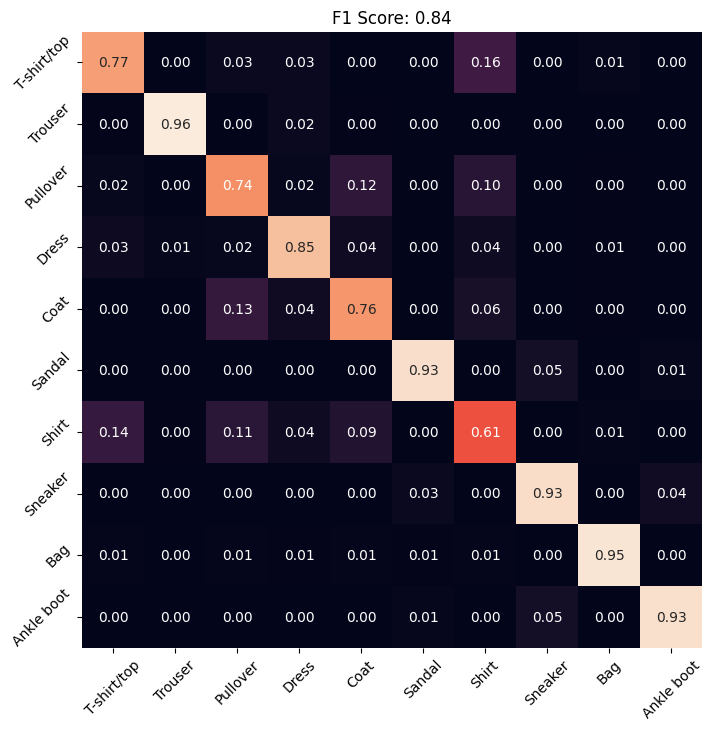

In [6]:
fig = plt.figure(figsize=[8, 8])
ax = fig.add_subplot(1, 1, 1)
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
seaborn.heatmap(confusion_matrix(y_test, predictions, normalize='true'), ax=ax, annot=True, fmt='1.2f', cbar=False, 
                xticklabels=classes, yticklabels=classes)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
ax.set_title('F1 Score: %1.2f' % f1_score(y_test, predictions, average='weighted'))

Overall, our model works pretty well. Not as good as our DCNNs, but it's actually really rather close to our simpler DCNNs while also being a much simpler method too. Note though that while it's simpler, it's not necessarily faster to train and evaluate.

## Final Thoughts

This has provide another example of how we can use dimension reduction and GMMs in combination. While this broad approach can use a number of dimension reduction and sub-space learning methods, it doesn't really work with any clustering method other than a GMM. This method relies on having a probabilistic model so that we can measure how likely it is that a sample arises from the distribution for the specific class. 

The dimension reduction method is critical here to make the GMMs easier to fit, as if keep the original high dimensional features we'll end up in a lot of trouble fitting those. For this reason, we also do things like use a diagonal covariance matrix to simplify the GMM, as we'll generally get better performance by having more components and a simpler covariance structure than fewer components will the full covariance matrix.

One thing we haven't look at here is trying to optimise our parameters. We have a few parameters across a number of steps, including any pre-processing/feature extraction, the number of PCA components we're keeping, and the number of GMM components (clusters) we're using. All of these are inter-related too, so if we change the number of PCA components, we'd expect to need to change, or at least re-evaluate, the number of GMM components as well.